# Part 2.5 Deep Learning: RNNs (LSTM & GRU)
In this notebook, we explore the middle ground between Traditional NLP and Transformers. We will build **Recurrent Neural Networks (RNNs)** using PyTorch.

We will cover:
1. **Word Embeddings & Padding**: Converting text into dense mathematical vectors of fixed lengths.
2. **PyTorch Datasets**: Building highly efficient data loaders.
3. **LSTM Model**: Building and training a Long Short-Term Memory network.
4. **GRU Model**: Building and training a Gated Recurrent Unit network.
5. **Evaluation**: Comparing them against our traditional models.

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from collections import Counter
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import time

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Load the data
print("Loading data...")
train_df = pd.read_csv('../data/imdb_train.csv')
test_df = pd.read_csv('../data/imdb_test.csv')

# Convert labels to 0 and 1
y_train_raw = train_df['sentiment'].map({"Negative": 0, "Positive": 1}).values
y_test_raw = test_df['sentiment'].map({"Negative": 0, "Positive": 1}).values

Using device: cpu
Loading data...


## Step 1 Tokenization, Vocabulary, and Padding
Unlike TF-IDF (which ignores word order), RNNs process text sequentially (word-by-word) from left to right.
1. We build a vocabulary of the top 10,000 most frequent words.
2. We map each word to a unique integer.
3. We **pad** all sentences to a fixed length (e.g., 200 words) so they fit into neat PyTorch tensors.

In [2]:
# Build Vocabulary
words = Counter()
for text in train_df['text']:
    words.update(text.lower().split())

# Use top 10,000 words
vocab_size = 10000
vocab = {w: i+2 for i, (w, c) in enumerate(words.most_common(vocab_size))}
vocab['<PAD>'] = 0  # Padding token
vocab['<UNK>'] = 1  # Unknown word token

# Encoding function
def encode_text(text, max_len=200):
    encoded = [vocab.get(w, 1) for w in text.lower().split()]
    if len(encoded) < max_len:
        # Pad with 0s at the end
        encoded += [0] * (max_len - len(encoded))
    else:
        # Truncate to max_len
        encoded = encoded[:max_len]
    return encoded

print("Encoding text into integer sequences...")
X_train = np.array([encode_text(t) for t in train_df['text']])
X_test = np.array([encode_text(t) for t in test_df['text']])

print("X_train shape:", X_train.shape)

Encoding text into integer sequences...
X_train shape: (25000, 200)


## Step 2 PyTorch DataLoaders
DataLoaders feed our data into the neural network in small "batches" (e.g., 64 reviews at a time) to avoid running out of memory.

In [4]:
batch_size = 64

# Convert numpy arrays to PyTorch Tensors
train_data = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train_raw).float())
test_data = TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test_raw).float())

train_loader = DataLoader(train_data, shuffle=True, batch_size=batch_size)
test_loader = DataLoader(test_data, shuffle=False, batch_size=batch_size)

print("DataLoaders created!")

DataLoaders created!


## Step 3  Define the LSTM & GRU Models
* **Embedding Layer**: Converts the integer token into a dense vector (e.g., 100 numbers).
* **RNN Layer (LSTM/GRU)**: Processes the sequence, remembering past context.
* **Linear Layer**: Squashes the final output into a single number.
* **Sigmoid**: Converts that number into a probability between 0 and 1.

In [5]:
class SentimentRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim, rnn_type='LSTM'):
        super().__init__()
        # Embedding layer
        self.embedding = nn.Embedding(vocab_size + 2, embed_dim, padding_idx=0)
        
        # RNN layer
        if rnn_type == 'LSTM':
            self.rnn = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        elif rnn_type == 'GRU':
            self.rnn = nn.GRU(embed_dim, hidden_dim, batch_first=True)
            
        self.rnn_type = rnn_type
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, text):
        # text shape: (batch_size, sequence_length)
        embedded = self.embedding(text)
        
        # RNN outputs: output, (hidden_state, cell_state) for LSTM
        # RNN outputs: output, hidden_state for GRU
        _, hidden = self.rnn(embedded)
        
        if self.rnn_type == 'LSTM':
            hidden = hidden[0]  # get the hidden state from the tuple
            
        # hidden shape: (1, batch_size, hidden_dim) -> squeeze to (batch_size, hidden_dim)
        hidden = hidden.squeeze(0)
        
        return self.sigmoid(self.fc(hidden))

# Define hyperparameters
embed_dim = 128
hidden_dim = 128
output_dim = 1

lstm_model = SentimentRNN(vocab_size, embed_dim, hidden_dim, output_dim, rnn_type='LSTM').to(device)
gru_model = SentimentRNN(vocab_size, embed_dim, hidden_dim, output_dim, rnn_type='GRU').to(device)

print(lstm_model)

SentimentRNN(
  (embedding): Embedding(10002, 128, padding_idx=0)
  (rnn): LSTM(128, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


## Step 4 Training Loop
We define a standard PyTorch training loop to adjust the model's weights using **Binary Cross Entropy Loss** and the **Adam optimizer**.

In [6]:
def train_model(model, train_loader, epochs=3):
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    model.train()
    for epoch in range(epochs):
        start_time = time.time()
        total_loss = 0
        correct = 0
        total = 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            # Zero gradients
            optimizer.zero_grad()
            
            # Forward pass
            predictions = model(inputs).squeeze()
            loss = criterion(predictions, labels)
            
            # Backward pass & optimize
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            
            # Calculate accuracy
            rounded_preds = torch.round(predictions)
            correct += (rounded_preds == labels).sum().item()
            total += labels.size(0)
            
        epoch_acc = correct / total
        elapsed = time.time() - start_time
        print(f"Epoch {epoch+1} | Loss: {total_loss/len(train_loader):.4f} | Acc: {epoch_acc:.4f} | Time: {elapsed:.2f}s")

# Training deep learning models takes time! 
# We are only running 2 epochs here for demonstration.
print("--- Training LSTM ---")
train_model(lstm_model, train_loader, epochs=2)

print("\n--- Training GRU ---")
train_model(gru_model, train_loader, epochs=2)

--- Training LSTM ---
Epoch 1 | Loss: 0.6929 | Acc: 0.5122 | Time: 137.67s
Epoch 2 | Loss: 0.6918 | Acc: 0.5257 | Time: 40.28s

--- Training GRU ---
Epoch 1 | Loss: 0.6944 | Acc: 0.5121 | Time: 172.52s
Epoch 2 | Loss: 0.6823 | Acc: 0.5542 | Time: 69.45s


## Step 5 Evaluation
Let's see how they perform on the test set.

Evaluating LSTM...
Evaluating GRU...

--- Results ---
LSTM Accuracy: 0.5011
GRU Accuracy : 0.6090


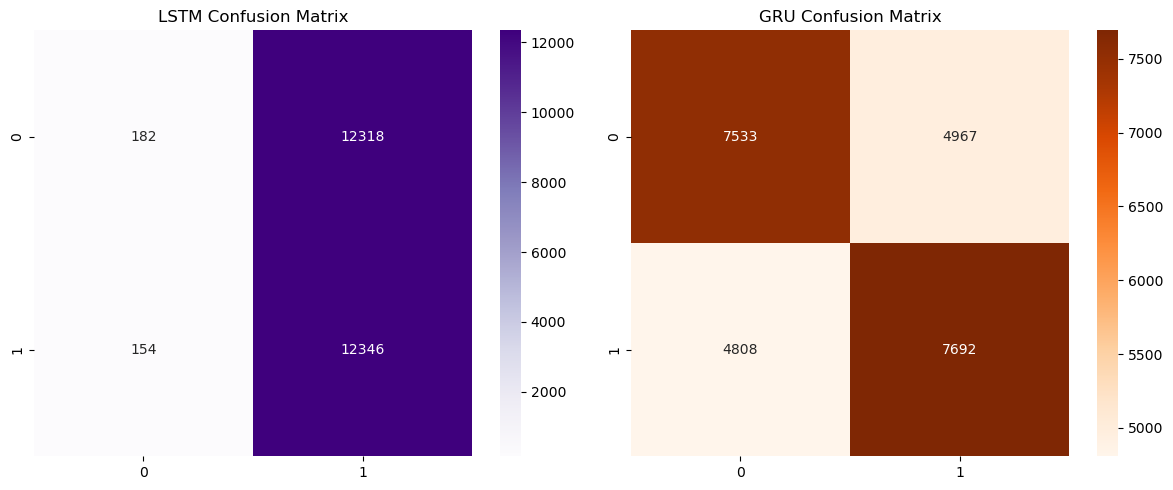

In [7]:
def evaluate_model(model, test_loader):
    model.eval()
    all_preds = []
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            predictions = model(inputs).squeeze()
            rounded_preds = torch.round(predictions)
            all_preds.extend(rounded_preds.cpu().numpy())
            
    return np.array(all_preds)

print("Evaluating LSTM...")
lstm_preds = evaluate_model(lstm_model, test_loader)
print("Evaluating GRU...")
gru_preds = evaluate_model(gru_model, test_loader)

print("\n--- Results ---")
print(f"LSTM Accuracy: {accuracy_score(y_test_raw, lstm_preds):.4f}")
print(f"GRU Accuracy : {accuracy_score(y_test_raw, gru_preds):.4f}")

# Plot Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(confusion_matrix(y_test_raw, lstm_preds), annot=True, fmt='d', cmap='Purples', ax=axes[0])
axes[0].set_title('LSTM Confusion Matrix')

sns.heatmap(confusion_matrix(y_test_raw, gru_preds), annot=True, fmt='d', cmap='Oranges', ax=axes[1])
axes[1].set_title('GRU Confusion Matrix')

plt.tight_layout()
plt.show()